# Hotel Booking Analysis

In [1]:
import csv
import os
import pandas as pd
import matplotlib.pyplot as plt
import re # For input validation

In [2]:
def print_com731(times):
    for _ in range(times):
        print("COM731")

In [3]:
def load_csv_as_list(file_path):
    data = []
    try:
        with open(file_path, 'r', newline='', encoding='utf-8') as file:
            reader = csv.reader(file)
            for row in reader:
                data.append(row)
        print("CSV file loaded successfully as a list.")
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred while loading the CSV: {e}")
    return data

def load_csv_as_dataframe(file_path):
    df = pd.DataFrame()
    try:
        df = pd.read_csv(file_path)
        print("CSV file loaded successfully as a DataFrame.")
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred while loading the CSV: {e}")
    return df

In [4]:
def get_column_indexes(header):
    if not header:
        return {}
    return {col: i for i, col in enumerate(header)}

In [5]:
def show_dataset_information(dataframe):
    if dataframe.empty:
        print("DataFrame is empty. No information to display.")
        return

    print("\nDataset Information:")
    print(dataframe.info())
    print("\nFirst 5 rows:")
    print(dataframe.head())
    print("\nDescriptive Statistics:")
    print(dataframe.describe(include='all'))

In [6]:
def seasonal_booking_patterns(column_indexes, list_data):
    if not list_data or len(list_data) < 2:
        print("No data available for analysis.")
        return
    print("\nSeasonal Booking Patterns Analysis")
    print_com731(3)

    header = list_data[0]
    data_rows = list_data[1:]

    arrival_date_month_idx = column_indexes.get('arrival_date_month')
    is_canceled_idx = column_indexes.get('is_canceled')

    if arrival_date_month_idx is None or is_canceled_idx is None:
        print("Required columns 'arrival_date_month' or 'is_canceled' not found.")
        return

    monthly_bookings = {}
    monthly_cancellations = {}

    for row in data_rows:
        if len(row) > max(arrival_date_month_idx, is_canceled_idx):
            month = row[arrival_date_month_idx]
            is_canceled = int(row[is_canceled_idx])

            monthly_bookings[month] = monthly_bookings.get(month, 0) + 1
            if is_canceled == 1:
                monthly_cancellations[month] = monthly_cancellations.get(month, 0) + 1

    # Sort months correctly (Jan, Feb, ..., Dec)
    month_order = ["January", "February", "March", "April", "May", "June",
                   "July", "August", "September", "October", "November", "December"]

    sorted_bookings = {month: monthly_bookings.get(month, 0) for month in month_order}
    sorted_cancellations = {month: monthly_cancellations.get(month, 0) for month in month_order}

    print("\nMonthly Bookings:")
    for month, count in sorted_bookings.items():
        print(f"{month}: {count} bookings")

    print("\nMonthly Cancellations:")
    for month, count in sorted_cancellations.items():
        print(f"{month}: {count} cancellations")

In [7]:
def guest_composition_details(column_indexes, list_data):
    if not list_data or len(list_data) < 2:
        print("No data available for analysis.")
        return
    print("\nGuest Composition Details")
    print_com731(3)

    header = list_data[0]
    data_rows = list_data[1:]

    adults_idx = column_indexes.get('adults')
    children_idx = column_indexes.get('children')
    babies_idx = column_indexes.get('babies')

    if any(idx is None for idx in [adults_idx, children_idx, babies_idx]):
        print("Required columns 'adults', 'children', or 'babies' not found.")
        return

    total_guests = {'adults': 0, 'children': 0, 'babies': 0}

    for row in data_rows:
        if len(row) > max(adults_idx, children_idx, babies_idx):
            try:
                total_guests['adults'] += int(row[adults_idx])
                total_guests['children'] += int(float(row[children_idx])) # Children can be float in some datasets
                total_guests['babies'] += int(row[babies_idx])
            except ValueError as e:
                # Handle cases where conversion to int fails, e.g., empty string or non-numeric
                # print(f"Skipping row due to non-numeric guest count: {row}, Error: {e}")
                continue
            except IndexError:
                # Handle cases where row might be malformed or too short
                # print(f"Skipping malformed row: {row}")
                continue

    print("\nTotal Guest Composition:")
    print(f"Adults: {total_guests['adults']}")
    print(f"Children: {total_guests['children']}")
    print(f"Babies: {total_guests['babies']}")

In [8]:
def booking_history_loyalty(column_indexes, list_data):
    if not list_data or len(list_data) < 2:
        print("No data available for analysis.")
        return
    print("\nBooking History and Loyalty Analysis (Task B3)")
    print_com731(3)

    header = list_data[0]
    data_rows = list_data[1:]

    customer_type_idx = column_indexes.get('customer_type')
    deposit_type_idx = column_indexes.get('deposit_type')
    is_repeated_guest_idx = column_indexes.get('is_repeated_guest')
    previous_cancellations_idx = column_indexes.get('previous_cancellations')
    previous_bookings_not_canceled_idx = column_indexes.get('previous_bookings_not_canceled')

    if any(idx is None for idx in [
        customer_type_idx,
        deposit_type_idx,
        is_repeated_guest_idx,
        previous_cancellations_idx,
        previous_bookings_not_canceled_idx
    ]):
        print("One or more required columns (customer_type, deposit_type, is_repeated_guest, previous_cancellations, previous_bookings_not_canceled) not found.")
        return

    # Get unique values for validation
    unique_customer_types = sorted(list(set(row[customer_type_idx] for row in data_rows if len(row) > customer_type_idx)))
    unique_deposit_types = sorted(list(set(row[deposit_type_idx] for row in data_rows if len(row) > deposit_type_idx)))

    while True:
        print(f"\nAvailable Customer Types: {', '.join(unique_customer_types)}")
        customer_type_input = input("Enter Customer Type (e.g., Transient, Contract, Group, Transient-Party): ").strip()
        if not customer_type_input:
            print("Customer type cannot be empty. Please try again.")
        elif customer_type_input not in unique_customer_types:
            print(f"Invalid Customer Type. Please choose from {', '.join(unique_customer_types)}.")
        else:
            break

    while True:
        print(f"\nAvailable Deposit Types: {', '.join(unique_deposit_types)}")
        deposit_type_input = input("Enter Deposit Type (e.g., No Deposit, Non Refund, Refundable): ").strip()
        if not deposit_type_input:
            print("Deposit type cannot be empty. Please try again.")
        elif deposit_type_input not in unique_deposit_types:
            print(f"Invalid Deposit Type. Please choose from {', '.join(unique_deposit_types)}.")
        else:
            break

    matching_bookings = []
    for i, row in enumerate(data_rows):
        if len(row) > max(customer_type_idx, deposit_type_idx, is_repeated_guest_idx, previous_cancellations_idx, previous_bookings_not_canceled_idx):
            try:
                current_customer_type = row[customer_type_idx]
                current_deposit_type = row[deposit_type_idx]

                if current_customer_type == customer_type_input and current_deposit_type == deposit_type_input:
                    matching_bookings.append({
                        'is_repeated_guest': int(row[is_repeated_guest_idx]),
                        'previous_cancellations': int(row[previous_cancellations_idx]),
                        'previous_bookings_not_canceled': int(row[previous_bookings_not_canceled_idx])
                    })
            except (ValueError, IndexError) as e:
                # print(f"Skipping row {i+1} due to data error: {e}")
                continue

    if not matching_bookings:
        print(f"No bookings found for customer type '{customer_type_input}' and deposit type '{deposit_type_input}'.")
        return

    # Calculate averages or sums for display
    total_repeated_guests = sum(b['is_repeated_guest'] for b in matching_bookings)
    total_previous_cancellations = sum(b['previous_cancellations'] for b in matching_bookings)
    total_previous_bookings_not_canceled = sum(b['previous_bookings_not_canceled'] for b in matching_bookings)

    print(f"\nResults for Customer Type: '{customer_type_input}', Deposit Type: '{deposit_type_input}'")
    print(f"Total matching bookings: {len(matching_bookings)}")
    print(f"Number of repeated guests: {total_repeated_guests}")
    print(f"Total previous cancellations: {total_previous_cancellations}")
    print(f"Total previous bookings not canceled: {total_previous_bookings_not_canceled}")

In [9]:
def custom_retrieval(column_indexes, list_data):
    if not list_data or len(list_data) < 2:
        print("No data available for analysis.")
        return
    print("\nCustom Data Retrieval (using multiple criteria)")
    print_com731(3)

    header = list_data[0]
    data_rows = list_data[1:]

    # Example: Retrieve bookings based on reservation_status, hotel, market_segment, customer_type, average_daily_rate
    res_status_idx = column_indexes.get('reservation_status')
    hotel_idx = column_indexes.get('hotel')
    market_segment_idx = column_indexes.get('market_segment')
    customer_type_idx = column_indexes.get('customer_type')
    adr_idx = column_indexes.get('adr')

    if any(idx is None for idx in [
        res_status_idx, hotel_idx, market_segment_idx, customer_type_idx, adr_idx
    ]):
        print("One or more required columns for custom retrieval not found.")
        return

    print("\n--- Custom Retrieval Criteria ---")

    unique_res_status = sorted(list(set(row[res_status_idx] for row in data_rows if len(row) > res_status_idx)))
    while True:
        print(f"Available Reservation Status: {', '.join(unique_res_status)}")
        res_status = input("Enter Reservation Status (e.g., Canceled, Check-Out, No-Show): ").strip()
        if not res_status:
            print("Reservation status cannot be empty. Please try again.")
        elif res_status not in unique_res_status:
            print(f"Invalid Reservation Status. Please choose from {', '.join(unique_res_status)}.")
        else:
            break

    unique_hotels = sorted(list(set(row[hotel_idx] for row in data_rows if len(row) > hotel_idx)))
    while True:
        print(f"Available Hotels: {', '.join(unique_hotels)}")
        hotel_type = input("Enter Hotel Type (e.g., City Hotel, Resort Hotel): ").strip()
        if not hotel_type:
            print("Hotel type cannot be empty. Please try again.")
        elif hotel_type not in unique_hotels:
            print(f"Invalid Hotel Type. Please choose from {', '.join(unique_hotels)}.")
        else:
            break

    try:
        min_adr = float(input("Enter Minimum Average Daily Rate (e.g., 50.0): ").strip())
        if min_adr < 0:
            print("Minimum ADR cannot be negative.")
            return
    except ValueError:
        print("Invalid input for minimum ADR. Please enter a number.")
        return

    matching_records = []
    for i, row in enumerate(data_rows):
        if len(row) > max(res_status_idx, hotel_idx, market_segment_idx, customer_type_idx, adr_idx):
            try:
                current_res_status = row[res_status_idx]
                current_hotel = row[hotel_idx]
                current_market_segment = row[market_segment_idx]
                current_customer_type = row[customer_type_idx]
                current_adr = float(row[adr_idx])

                if (current_res_status == res_status and
                    current_hotel == hotel_type and
                    current_adr >= min_adr):
                    matching_records.append({
                        'reservation_status': current_res_status,
                        'hotel': current_hotel,
                        'market_segment': current_market_segment,
                        'customer_type': current_customer_type,
                        'adr': current_adr
                    })
            except (ValueError, IndexError) as e:
                # print(f"Skipping row {i+1} due to data error: {e}")
                continue

    if not matching_records:
        print("No records found matching your criteria.")
        return

    print("\n--- Matching Records (First 10) ---")
    for record in matching_records[:10]: # Displaying first 10 for brevity
        print(record)
    if len(matching_records) > 10:
        print(f"... and {len(matching_records) - 10} more records.")
    print(f"Total records found: {len(matching_records)}")

In [10]:
def retrieval_menu(header, list_data, column_indexes):
    while True:
        print("\nData Retrieval Menu")
        print("1. Seasonal booking patterns")
        print("2. Guest composition")
        print("3. Booking history and loyalty")
        print("4. Custom retrieval")
        print("0. Back")

        choice = input("Enter your choice: ").strip()

        if choice == '1':
            seasonal_booking_patterns(column_indexes, list_data)
            print_com731(2)
        elif choice == '2':
            guest_composition_details(column_indexes, list_data)
            print_com731(2)
        elif choice == '3':
            booking_history_loyalty(column_indexes, list_data)
            print_com731(2)
        elif choice == '4':
            custom_retrieval(column_indexes, list_data)
            print_com731(2)
        elif choice == '0':
            break
        else:
            print("Invalid choice. Please try again.")

In [11]:
def top_market_segments(dataframe):
    if dataframe.empty:
        print("DataFrame is empty. No analysis possible.")
        return
    print("\nTop Market Segments Analysis (Task C1)")
    print_com731(3)

    if 'distribution_channel' not in dataframe.columns or 'country' not in dataframe.columns or \
       'market_segment' not in dataframe.columns or 'lead_time' not in dataframe.columns:
        print("Required columns (distribution_channel, country, market_segment, lead_time) not found.")
        return

    unique_channels = dataframe['distribution_channel'].unique().tolist()
    while True:
        print(f"\nAvailable Distribution Channels: {', '.join(unique_channels)}")
        channel = input("Enter Distribution Channel (e.g., Corporate, TA/TO, Direct): ").strip()
        if not channel:
            print("Distribution channel cannot be empty. Please try again.")
        elif channel not in unique_channels:
            print(f"Invalid Distribution Channel. Please choose from {', '.join(unique_channels)}.")
        else:
            break

    # Using regex to allow partial matches for country as per usual data entry
    unique_countries = dataframe['country'].dropna().unique().tolist()
    while True:
        country_input = input("Enter Country (e.g., PRT, GBR, FRA - leave empty for all): ").strip().upper()
        if country_input == '':
            print("Analyzing all countries.")
            break
        # Simple check for direct match first
        if country_input in unique_countries:
            break
        else:
            # If not a direct match, offer suggestions or re-prompt
            matches = [c for c in unique_countries if country_input in c]
            if matches:
                print(f"Did you mean one of these? {', '.join(matches)}")
            print(f"Invalid or unrecognized country code. Available: {', '.join(unique_countries[:10])}... Please try again.")


    filtered_df = dataframe[dataframe['distribution_channel'] == channel]
    if country_input:
        filtered_df = filtered_df[filtered_df['country'] == country_input]

    if filtered_df.empty:
        print("No data found for the selected distribution channel and country.")
        return

    # Group by market segment and calculate average lead time
    market_segment_lead_time = filtered_df.groupby('market_segment')['lead_time'].mean().reset_index()
    market_segment_lead_time = market_segment_lead_time.sort_values(by='lead_time', ascending=False)

    print(f"\nTop 3 Market Segments by Average Lead Time for Channel '{channel}' and Country '{country_input if country_input else 'All'}'")
    print(market_segment_lead_time.head(3))

In [12]:
def room_assignment_analysis(dataframe):
    if dataframe.empty:
        print("DataFrame is empty. No analysis possible.")
        return
    print("\nRoom Assignment Analysis (Task C2)")
    print_com731(3)

    if 'reserved_room_type' not in dataframe.columns or 'assigned_room_type' not in dataframe.columns or \
       'is_canceled' not in dataframe.columns:
        print("Required columns (reserved_room_type, assigned_room_type, is_canceled) not found.")
        return

    # Filter for non-canceled bookings
    non_canceled_bookings = dataframe[dataframe['is_canceled'] == 0].copy()

    if non_canceled_bookings.empty:
        print("No non-canceled bookings to analyze.")
        return

    # Calculate if reserved room type matches assigned room type
    non_canceled_bookings.loc[:, 'room_match'] = (
        non_canceled_bookings['reserved_room_type'] == non_canceled_bookings['assigned_room_type']
    )

    # Group by hotel type and calculate the proportion of room matches
    room_match_proportion = non_canceled_bookings.groupby('hotel')['room_match'].mean() * 100

    print("\nProportion of Room Type Matches for Non-Canceled Bookings (by Hotel Type):")
    print(room_match_proportion)

    # Group by reserved room type and calculate the proportion of room matches
    room_match_by_reserved_type = non_canceled_bookings.groupby('reserved_room_type')['room_match'].mean() * 100

    print("\nProportion of Room Type Matches for Non-Canceled Bookings (by Reserved Room Type):")
    print(room_match_by_reserved_type)

In [13]:
def guest_preference_analysis(dataframe):
    if dataframe.empty:
        print("DataFrame is empty. No analysis possible.")
        return
    print("\nGuest Preference Analysis (Task C3)")
    print_com731(3)

    required_cols = ['meal', 'adr', 'reservation_status', 'total_of_special_requests', 'required_car_parking_spaces', 'booking_changes']
    if not all(col in dataframe.columns for col in required_cols):
        print(f"Required columns not found: {', '.join([col for col in required_cols if col not in dataframe.columns])}")
        return

    unique_meals = dataframe['meal'].unique().tolist()
    while True:
        print(f"\nAvailable Meal Types: {', '.join(unique_meals)}")
        meal_type = input("Enter Meal Type (e.g., BB, FB, HB, SC, Undefined): ").strip()
        if not meal_type:
            print("Meal type cannot be empty. Please try again.")
        elif meal_type not in unique_meals:
            print(f"Invalid Meal Type. Please choose from {', '.join(unique_meals)}.")
        else:
            break

    # 1. Calculate the average ADR for that meal type
    avg_adr_for_meal = dataframe[dataframe['meal'] == meal_type]['adr'].mean()
    if pd.isna(avg_adr_for_meal):
        print(f"No ADR data available for meal type '{meal_type}'.")
        return
    print(f"Average ADR for '{meal_type}' meal type: {avg_adr_for_meal:.2f}")

    # 2. Keep bookings above that meal-specific average ADR
    filtered_df = dataframe[dataframe['adr'] > avg_adr_for_meal].copy()

    if filtered_df.empty:
        print(f"No bookings found with ADR above the average for '{meal_type}'.")
        return

    # 3. Group by reservation status
    # 4. Calculate averages of: total_of_special_requests, required_car_parking_spaces, booking_changes
    preference_summary = filtered_df.groupby('reservation_status').agg(
        average_special_requests=('total_of_special_requests', 'mean'),
        average_car_parking_spaces=('required_car_parking_spaces', 'mean'),
        average_booking_changes=('booking_changes', 'mean')
    ).reset_index()

    print(f"\nGuest Preferences for bookings with '{meal_type}' meal type and ADR > {avg_adr_for_meal:.2f}:")
    print(preference_summary)

In [14]:
def custom_pandas_analysis(dataframe):
    if dataframe.empty:
        print("DataFrame is empty. No analysis possible.")
        return
    print("\nCustom Pandas Analysis")
    print_com731(3)

    required_cols = ['lead_time', 'market_segment', 'total_of_special_requests', 'booking_changes']
    if not all(col in dataframe.columns for col in required_cols):
        print(f"Required columns not found: {', '.join([col for col in required_cols if col not in dataframe.columns])}")
        return

    # Custom condition: bookings with lead_time > 100 days and 'Direct' market segment
    # Using lead_time, total_of_special_requests, booking_changes as the three columns
    print("\nAnalyzing bookings with lead time > 100 days from 'Direct' market segment.")

    filtered_df = dataframe[
        (dataframe['lead_time'] > 100) &
        (dataframe['market_segment'] == 'Direct')
    ].copy()

    if filtered_df.empty:
        print("No bookings found matching the custom criteria (lead_time > 100 and market_segment == 'Direct').")
        return

    # Group by 'is_canceled' to see if cancellation patterns differ for these long lead-time direct bookings
    custom_analysis_result = filtered_df.groupby('is_canceled').agg(
        mean_lead_time=('lead_time', 'mean'),
        total_special_requests_sum=('total_of_special_requests', 'sum'),
        mean_booking_changes=('booking_changes', 'mean'),
        count=('is_canceled', 'size')
    ).reset_index()

    print("\nSummary of Long Lead-Time 'Direct' Bookings by Cancellation Status:")
    print(custom_analysis_result)
    print("\nInterpretation: This analysis helps understand if long lead-time direct bookings behave differently regarding special requests or booking changes, and their cancellation rates.")

In [15]:
def analysis_menu(dataframe):
    while True:
        print("\nData Analysis Menu")
        print("1. Top market segments")
        print("2. Room assignment analysis")
        print("3. Guest preference analysis")
        print("4. Custom Pandas analysis")
        print("0. Back")

        choice = input("Enter your choice: ").strip()

        if choice == '1':
            top_market_segments(dataframe)
            print_com731(2)
        elif choice == '2':
            room_assignment_analysis(dataframe)
            print_com731(2)
        elif choice == '3':
            guest_preference_analysis(dataframe)
            print_com731(2)
        elif choice == '4':
            custom_pandas_analysis(dataframe)
            print_com731(2)
        elif choice == '0':
            break
        else:
            print("Invalid choice. Please try again.")

In [16]:
def customer_stay_trends(dataframe):
    if dataframe.empty:
        print("DataFrame is empty. No visualization possible.")
        return
    print("\nCustomer Stay Trends (Line Chart - Task D1)")
    print_com731(3)

    required_cols = ['country', 'arrival_date_year', 'arrival_date_month', 'stays_in_weekend_nights', 'customer_type']
    if not all(col in dataframe.columns for col in required_cols):
        print(f"Required columns not found: {', '.join([col for col in required_cols if col not in dataframe.columns])}")
        return

    # Data Cleaning / Preparation
    df_plot = dataframe.copy()
    df_plot['total_nights'] = df_plot['stays_in_weekend_nights'] + df_plot['stays_in_week_nights']

    # Convert month names to numbers for sorting
    month_map = {
        'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
        'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
    }
    df_plot['arrival_date_month_num'] = df_plot['arrival_date_month'].map(month_map)

    # Input for country
    unique_countries = df_plot['country'].dropna().unique().tolist()
    while True:
        country_input = input("Enter Country (e.g., PRT, GBR, FRA - leave empty for all): ").strip().upper()
        if country_input == '':
            print("Analyzing all countries.")
            break
        if country_input in unique_countries:
            break
        else:
            matches = [c for c in unique_countries if country_input in c]
            if matches:
                print(f"Did you mean one of these? {', '.join(matches)}")
            print(f"Invalid or unrecognized country code. Available: {', '.join(unique_countries[:10])}... Please try again.")

    # Input for year
    unique_years = sorted(df_plot['arrival_date_year'].dropna().unique().tolist())
    while True:
        try:
            year_input_str = input(f"Enter Year (e.g., {unique_years[0]}, {unique_years[1]} - leave empty for all): ").strip()
            if year_input_str == '':
                year_input = None
                print("Analyzing all years.")
                break
            year_input = int(year_input_str)
            if year_input not in unique_years:
                print(f"Invalid year. Please choose from {', '.join(map(str, unique_years))}.")
            else:
                break
        except ValueError:
            print("Invalid year input. Please enter a number or leave empty.")

    filtered_df = df_plot.copy()
    if country_input:
        filtered_df = filtered_df[filtered_df['country'] == country_input]
    if year_input is not None:
        filtered_df = filtered_df[filtered_df['arrival_date_year'] == year_input]

    if filtered_df.empty:
        print("No data found for the selected criteria.")
        return

    # Group by month and customer type for average weekend nights
    # Also group by total_nights for general trends (a bit of a deviation from exact 'weekend nights' but more meaningful for 'stay trends')
    monthly_trends = filtered_df.groupby(['arrival_date_month_num', 'arrival_date_month', 'customer_type']).agg(
        avg_weekend_nights=('stays_in_weekend_nights', 'mean'),
        avg_total_nights=('total_nights', 'mean')
    ).reset_index().sort_values(by='arrival_date_month_num')

    if monthly_trends.empty:
        print("No monthly trends to display for the given criteria.")
        return

    plt.figure(figsize=(12, 7))
    sns.lineplot(data=monthly_trends, x='arrival_date_month', y='avg_total_nights', hue='customer_type', marker='o')
    plt.title(f"Monthly Average Total Nights by Customer Type for {country_input if country_input else 'All Countries'} in {year_input if year_input else 'All Years'}")
    plt.xlabel("Month")
    plt.ylabel("Average Total Nights")
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [17]:
import seaborn as sns

def adr_vs_total_nights(dataframe):
    if dataframe.empty:
        print("DataFrame is empty. No visualization possible.")
        return
    print("\nADR vs. Total Nights (Scatter Plot - Task D2)")
    print_com731(3)

    required_cols = ['adr', 'stays_in_weekend_nights', 'stays_in_week_nights', 'is_canceled']
    if not all(col in dataframe.columns for col in required_cols):
        print(f"Required columns not found: {', '.join([col for col in required_cols if col not in dataframe.columns])}")
        return

    df_plot = dataframe.copy()
    df_plot['total_nights'] = df_plot['stays_in_weekend_nights'] + df_plot['stays_in_week_nights']

    # Filter out bookings with ADR <= 0 or total_nights <= 0 for better visualization
    df_plot = df_plot[(df_plot['adr'] > 0) & (df_plot['total_nights'] > 0)]

    if df_plot.empty:
        print("No valid data (ADR > 0 and total_nights > 0) for plotting.")
        return

    # User input for minimum total nights (validation for negative numbers)
    while True:
        try:
            min_nights_str = input("Enter minimum total nights (e.g., 1, 5, 10): ").strip()
            min_nights = int(min_nights_str)
            if min_nights < 0:
                print("Minimum nights cannot be negative. Please try again.")
            else:
                break
        except ValueError:
            print("Invalid input. Please enter an integer.")

    df_plot = df_plot[df_plot['total_nights'] >= min_nights]

    if df_plot.empty:
        print(f"No bookings found with total nights greater than or equal to {min_nights}.")
        return

    plt.figure(figsize=(12, 7))
    sns.scatterplot(data=df_plot, x='total_nights', y='adr', hue='is_canceled', alpha=0.6, s=20)
    plt.title(f"Average Daily Rate (ADR) vs. Total Nights (Min. {min_nights} Nights)")
    plt.xlabel("Total Nights of Stay")
    plt.ylabel("Average Daily Rate (ADR)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [18]:
def special_request_analysis(dataframe):
    if dataframe.empty:
        print("DataFrame is empty. No visualization possible.")
        return
    print("\nSpecial Request Analysis (Pie Chart - Task D3)")
    print_com731(3)

    required_cols = ['deposit_type', 'customer_type', 'total_of_special_requests']
    if not all(col in dataframe.columns for col in required_cols):
        print(f"Required columns not found: {', '.join([col for col in required_cols if col not in dataframe.columns])}")
        return

    unique_deposit_types = dataframe['deposit_type'].unique().tolist()
    while True:
        print(f"\nAvailable Deposit Types: {', '.join(unique_deposit_types)}")
        deposit_type_input = input("Enter Deposit Type to filter (e.g., No Deposit, Non Refund, Refundable): ").strip()
        if not deposit_type_input:
            print("Deposit type cannot be empty. Please try again.")
        elif deposit_type_input not in unique_deposit_types:
            print(f"Invalid Deposit Type. Please choose from {', '.join(unique_deposit_types)}.")
        else:
            break

    filtered_df = dataframe[dataframe['deposit_type'] == deposit_type_input].copy()

    if filtered_df.empty:
        print(f"No bookings found for deposit type '{deposit_type_input}'.")
        return

    # Group by customer type and calculate mean special requests
    special_requests_by_customer = filtered_df.groupby('customer_type')['total_of_special_requests'].mean().reset_index()

    if special_requests_by_customer.empty:
        print("No special request data to plot for the filtered selection.")
        return

    # Convert mean special requests to proportions for a pie chart
    # A pie chart of 'average number of special requests' doesn't make direct sense.
    # Instead, let's represent the proportion of *bookings with any special requests* by customer type.
    # Or, proportion of total special requests from each customer type.

    # Let's go with the proportion of total special requests made by each customer type
    # relative to the sum of special requests in the filtered data.
    total_special_requests = filtered_df['total_of_special_requests'].sum()
    if total_special_requests == 0:
        print("No special requests made in the filtered data. Cannot create pie chart.")
        return

    # Group by customer type and sum special requests
    sum_special_requests_by_customer = filtered_df.groupby('customer_type')['total_of_special_requests'].sum().reset_index()
    sum_special_requests_by_customer['proportion'] = (sum_special_requests_by_customer['total_of_special_requests'] / total_special_requests) * 100

    plt.figure(figsize=(10, 8))
    plt.pie(sum_special_requests_by_customer['proportion'],
            labels=sum_special_requests_by_customer['customer_type'],
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
    plt.title(f"Proportion of Total Special Requests by Customer Type (for '{deposit_type_input}' Deposit Type)")
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.tight_layout()
    plt.show()

In [19]:
def custom_visualization(dataframe):
    if dataframe.empty:
        print("DataFrame is empty. No visualization possible.")
        return
    print("\nCustom Visualization (Vertical Bar Chart)")
    print_com731(3)

    required_cols = ['hotel', 'arrival_date_month', 'adr']
    if not all(col in dataframe.columns for col in required_cols):
        print(f"Required columns not found: {', '.join([col for col in required_cols if col not in dataframe.columns])}")
        return

    unique_hotels = dataframe['hotel'].unique().tolist()
    while True:
        print(f"\nAvailable Hotel Types: {', '.join(unique_hotels)}")
        hotel_type_input = input("Enter Hotel Type (e.g., City Hotel, Resort Hotel - leave empty for all): ").strip()
        if not hotel_type_input:
            print("Analyzing all hotel types.")
            break
        elif hotel_type_input not in unique_hotels:
            print(f"Invalid Hotel Type. Please choose from {', '.join(unique_hotels)}.")
        else:
            break

    filtered_df = dataframe.copy()
    if hotel_type_input:
        filtered_df = filtered_df[filtered_df['hotel'] == hotel_type_input]

    if filtered_df.empty:
        print("No data found for the selected hotel type.")
        return

    # Convert month names to numbers for sorting
    month_map = {
        'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
        'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
    }
    filtered_df['arrival_date_month_num'] = filtered_df['arrival_date_month'].map(month_map)

    # Calculate monthly average ADR
    monthly_avg_adr = filtered_df.groupby(['arrival_date_month_num', 'arrival_date_month'])['adr'].mean().reset_index()
    monthly_avg_adr = monthly_avg_adr.sort_values(by='arrival_date_month_num')

    if monthly_avg_adr.empty:
        print("No monthly ADR data to plot for the filtered selection.")
        return

    plt.figure(figsize=(12, 7))
    sns.barplot(x='arrival_date_month', y='adr', data=monthly_avg_adr, palette='viridis')
    plt.title(f"Monthly Average Daily Rate (ADR) for {hotel_type_input if hotel_type_input else 'All Hotels'}")
    plt.xlabel("Month of Arrival")
    plt.ylabel("Average Daily Rate (ADR)")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [20]:
def visualisation_menu(dataframe):
    while True:
        print("\nData Visualisation Menu")
        print("1. Customer Stay Trends (Line Chart)")
        print("2. ADR vs. Total Nights (Scatter Plot)")
        print("3. Special Request Analysis (Pie Chart)")
        print("4. Custom Visualization (Bar Chart)")
        print("0. Back")

        choice = input("Enter your choice: ").strip()

        if choice == '1':
            customer_stay_trends(dataframe)
            print_com731(2)
        elif choice == '2':
            adr_vs_total_nights(dataframe)
            print_com731(2)
        elif choice == '3':
            special_request_analysis(dataframe)
            print_com731(2)
        elif choice == '4':
            custom_visualization(dataframe)
            print_com731(2)
        elif choice == '0':
            break
        else:
            print("Invalid choice. Please try again.")

In [21]:
def main_menu(header, list_data, dataframe, column_indexes):
    while True:
        print("\nMain Menu")
        print("1. Show Dataset Information")
        print("2. Data Retrieval")
        print("3. Data Analysis")
        print("4. Data Visualisation")
        print("0. Exit")

        choice = input("Enter your choice: ").strip()

        if choice == '1':
            show_dataset_information(dataframe)
            print_com731(2)
        elif choice == '2':
            retrieval_menu(header, list_data, column_indexes)
            print_com731(2)
        elif choice == '3':
            analysis_menu(dataframe)
            print_com731(2)
        elif choice == '4':
            visualisation_menu(dataframe)
            print_com731(2)
        elif choice == '0':
            print("Exiting program. Goodbye!")
            break
        else:
            print("Invalid choice. Please try again.")

COM731
COM731

Welcome to the Hotel Booking Analysis System!
Enter the CSV file name or path (e.g., hotel_booking (1) (1).csv): /content/hotel_booking (1) (1).csv
CSV file loaded successfully as a list.
CSV file loaded successfully as a DataFrame.

Main Menu
1. Show Dataset Information
2. Data Retrieval
3. Data Analysis
4. Data Visualisation
0. Exit
Enter your choice: 1

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118898 entries, 0 to 118897
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118898 non-null  object 
 1   is_canceled                     118898 non-null  int64  
 2   lead_time                       118898 non-null  int64  
 3   arrival_date_year               118898 non-null  int64  
 4   arrival_date_month              118898 non-null  object 
 5   arrival_date_week_number        118898 non-null  int64 

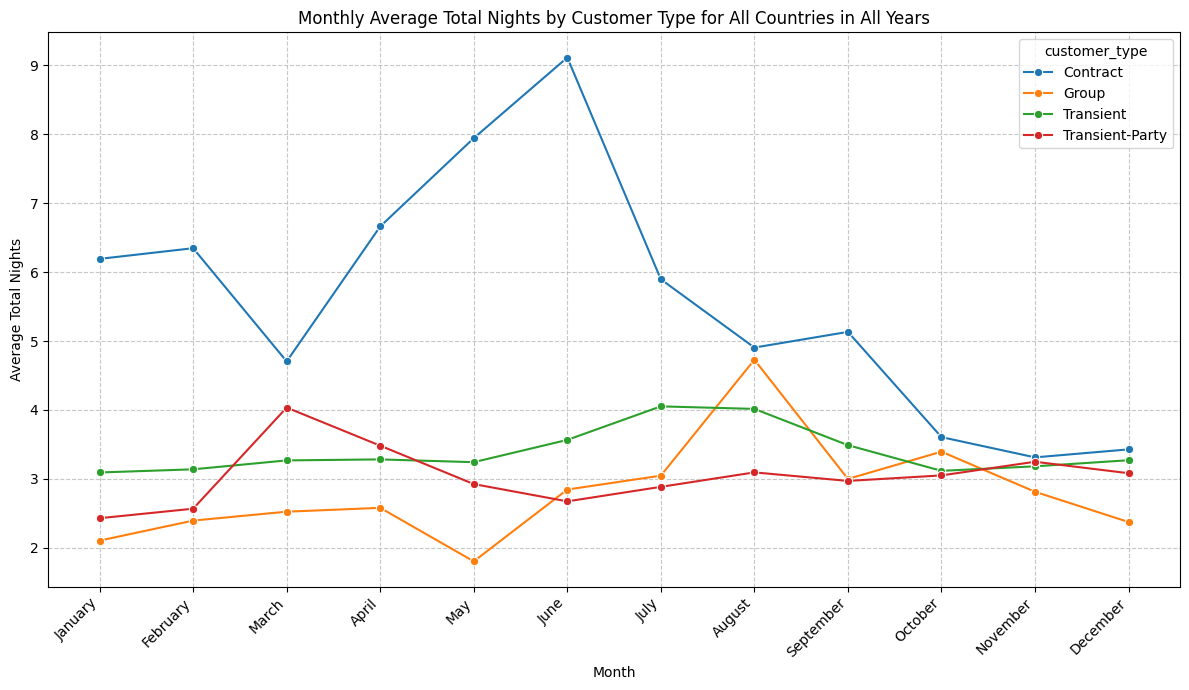

COM731
COM731

Data Visualisation Menu
1. Customer Stay Trends (Line Chart)
2. ADR vs. Total Nights (Scatter Plot)
3. Special Request Analysis (Pie Chart)
4. Custom Visualization (Bar Chart)
0. Back


In [ ]:
print_com731(2)
print("\nWelcome to the Hotel Booking Analysis System!")

file_path = input("Enter the CSV file name or path (e.g., hotel_booking (1) (1).csv): ").strip()

list_data = []
dataframe = pd.DataFrame()
header = []
column_indexes = {}

if file_path:
    if os.path.exists(file_path):
        list_data = load_csv_as_list(file_path)
        if list_data:
            header = list_data[0]
            column_indexes = get_column_indexes(header)
        dataframe = load_csv_as_dataframe(file_path)
    else:
        print(f"The file '{file_path}' does not exist. Please check the path and try again.")
else:
    print("No file path entered. Cannot load data.")

if not dataframe.empty and list_data:
    main_menu(header, list_data, dataframe, column_indexes)
else:
    print("The program cannot start because the dataset was not loaded successfully.")
